# EDA - Olist Brazilian E-Commerce Dataset

**Ziel:** Datenqualität, Struktur und Beziehungen verstehen — als Grundlage für die Pipeline-Architektur und dbt-Modelle.

**Business Questions im Blick:**
- BQ-01: Welche Produkte/Kategorien bringen den meisten Umsatz?
- BQ-02: Welche Regionen performen am besten?
- BQ-03: Wie lange dauert die Lieferung — wo gibt es Verzögerungen?
- BQ-04: Wie zufrieden sind die Kunden?

**Schema:** Shape → dtypes → Nulls → Duplikate → Stichprobe → Key Stats

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
sns.set_theme(style='whitegrid', palette='muted')

RAW = Path('../data/raw')
print('Dateien in data/raw:')
for f in sorted(RAW.glob('*.csv')):
    print(' ', f.name)

Dateien in data/raw:
  olist_customers_dataset.csv
  olist_geolocation_dataset.csv
  olist_order_items_dataset.csv
  olist_order_payments_dataset.csv
  olist_order_reviews_dataset.csv
  olist_orders_dataset.csv
  olist_products_dataset.csv
  olist_sellers_dataset.csv
  product_category_name_translation.csv


---
## Hilfsfunktion: Tabellen-Profil

Eine Funktion, die wir für jede Tabelle aufrufen — damit wir konsistente Ausgaben bekommen.

In [6]:
def profile(df: pd.DataFrame, name: str) -> None:
    """Gibt ein kompaktes Profil einer DataFrame aus."""
    print(f'\n===== {name} =====')
    print(f'Shape:      {df.shape[0]:,} Zeilen × {df.shape[1]} Spalten')
    print(f'Duplikate:  {df.duplicated().sum():,}')
    print()

    # dtypes + Nulls zusammen
    null_info = pd.DataFrame({
        'dtype':    df.dtypes,
        'nulls':    df.isnull().sum(),
        'null_%':   (df.isnull().mean() * 100).round(2)
    })
    print(null_info.to_string())
    print()
    print('--- Stichprobe (3 Zeilen) ---')
    display(df.sample(3, random_state=42))

---
## 1. olist_orders_dataset  
**Kerntabelle** — verbindet alles. Enthält Status, Timestamps (Kauf, Genehmigung, Lieferung).

Relevant für: BQ-03 (Lieferdauer), BQ-04 (Bestellstatus)

In [5]:
orders = pd.read_csv(RAW / 'olist_orders_dataset.csv', parse_dates=[
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])
profile(orders, 'orders')


===== orders =====
Shape:      99,441 Zeilen × 8 Spalten
Duplikate:  0

                                        dtype  nulls  null_%
order_id                                  str      0    0.00
customer_id                               str      0    0.00
order_status                              str      0    0.00
order_purchase_timestamp       datetime64[us]      0    0.00
order_approved_at              datetime64[us]    160    0.16
order_delivered_carrier_date   datetime64[us]   1783    1.79
order_delivered_customer_date  datetime64[us]   2965    2.98
order_estimated_delivery_date  datetime64[us]      0    0.00

--- Stichprobe (3 Zeilen) ---


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
52263,b9a6c5f5df52c7226ac85aee7524c27f,f160aaf480efdfa7268f0fa535f73e76,delivered,2018-06-12 20:07:44,2018-06-12 20:44:26,2018-06-13 13:09:00,2018-06-19 12:44:08,2018-07-17
46645,261e71d2349c713eafa9f3df5972b95d,d6708bbbd2d419475869a84e41f620a1,delivered,2018-01-20 12:15:57,2018-01-20 12:37:13,2018-01-25 21:42:52,2018-01-30 11:32:35,2018-02-15
37546,67b50899f52995848c427e361e10dde3,1b353c00c71689afba44554e43cc5a76,delivered,2018-06-16 21:24:10,2018-06-16 21:36:59,2018-06-21 13:55:00,2018-06-27 13:17:27,2018-07-16


In [7]:
# Bestellstatus-Verteilung
print(orders['order_status'].value_counts())

# Zeitraum des Datensatzes
print(f"\nZeitraum: {orders['order_purchase_timestamp'].min().date()} → {orders['order_purchase_timestamp'].max().date()}")

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Zeitraum: 2016-09-04 → 2018-10-17


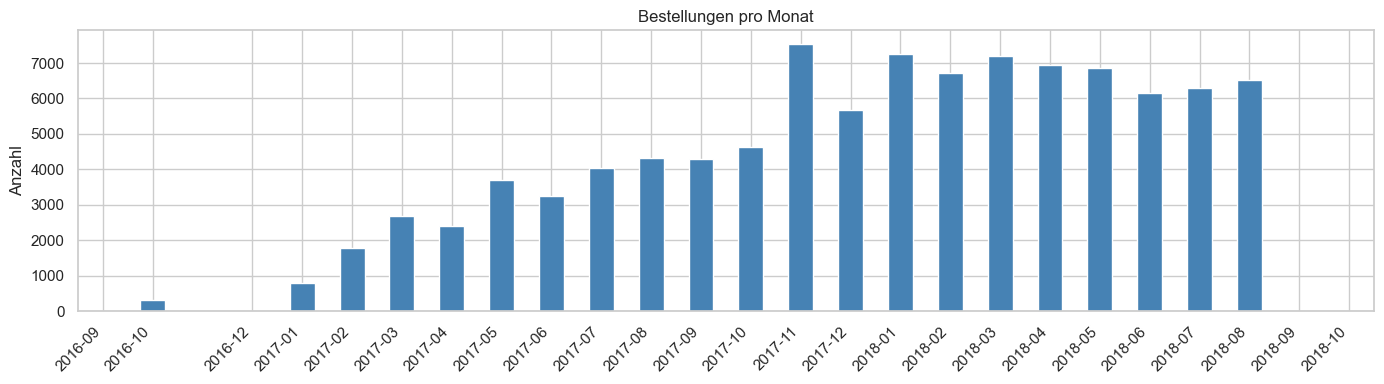

In [8]:
# Bestellungen pro Monat — gibt Saisonalität und Datenlücken
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M')
monthly = orders.groupby('month').size()

fig, ax = plt.subplots(figsize=(14, 4))
monthly.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Bestellungen pro Monat')
ax.set_xlabel('')
ax.set_ylabel('Anzahl')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 2. olist_order_items_dataset  
Jede Zeile = ein Artikel in einer Bestellung. Enthält Preis, Frachtkosten, Seller.

Relevant für: BQ-01 (Umsatz), BQ-02 (Seller-Region)

In [9]:
items = pd.read_csv(RAW / 'olist_order_items_dataset.csv', parse_dates=['shipping_limit_date'])
profile(items, 'order_items')


===== order_items =====
Shape:      112,650 Zeilen × 7 Spalten
Duplikate:  0

                              dtype  nulls  null_%
order_id                        str      0     0.0
order_item_id                 int64      0     0.0
product_id                      str      0     0.0
seller_id                       str      0     0.0
shipping_limit_date  datetime64[us]      0     0.0
price                       float64      0     0.0
freight_value               float64      0     0.0

--- Stichprobe (3 Zeilen) ---


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
107777,f4ee4273538924bda6212f5948e80fde,1,69455f41626a745aea9ee9164cb9eafd,7d13fca15225358621be4086e1eb0964,2018-06-19 09:18:15,180.00,20.45
2391,056349f85a73d794119c4286c95a52de,1,af35be35db4ad0dc288b571453337376,d20b021d3efdf267a402c402a48ea64b,2017-03-09 14:35:09,10.99,16.05
77829,b124967afcc82ef17ec41020fe2a9136,1,12e6d0f655986ceff00c74658dec97b1,3be634553519fb6536a03e1358e9fdc7,2018-06-06 17:18:09,49.99,8.88


Umsatz gesamt (price):       R$ 13,591,643.70
Frachtkosten gesamt:         R$ 2,251,909.54
Ø Preis pro Artikel:         R$ 120.65
Max items_per_order:         21


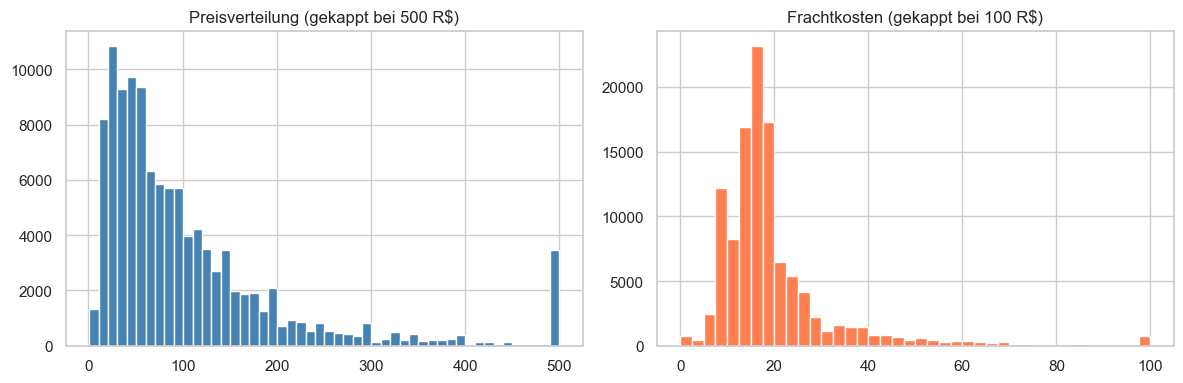

In [10]:
print(f"Umsatz gesamt (price):       R$ {items['price'].sum():,.2f}")
print(f"Frachtkosten gesamt:         R$ {items['freight_value'].sum():,.2f}")
print(f"Ø Preis pro Artikel:         R$ {items['price'].mean():,.2f}")
print(f"Max items_per_order:         {items.groupby('order_id')['order_item_id'].max().max()}")

# Preisverteilung
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
items['price'].clip(upper=500).hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Preisverteilung (gekappt bei 500 R$)')
items['freight_value'].clip(upper=100).hist(bins=40, ax=axes[1], color='coral')
axes[1].set_title('Frachtkosten (gekappt bei 100 R$)')
plt.tight_layout()
plt.show()

---
## 3. olist_order_payments_dataset  
Zahlungsarten und -werte je Bestellung. Eine Bestellung kann mehrere Zahlungen haben.

Relevant für: BQ-01 (tatsächlicher Umsatz)

In [11]:
payments = pd.read_csv(RAW / 'olist_order_payments_dataset.csv')
profile(payments, 'order_payments')


===== order_payments =====
Shape:      103,886 Zeilen × 5 Spalten
Duplikate:  0

                        dtype  nulls  null_%
order_id                  str      0     0.0
payment_sequential      int64      0     0.0
payment_type              str      0     0.0
payment_installments    int64      0     0.0
payment_value         float64      0     0.0

--- Stichprobe (3 Zeilen) ---


,order_id,payment_sequential,payment_type,payment_installments,payment_value
21856,61c7b1cf28b58654fe411aaf87fe249d,1,debit_card,1,39.60
82913,a01f943f4a95572159f0603bd160d67a,1,credit_card,1,111.42
81375,267968a4442f2e55c2904cac31c26660,1,credit_card,1,37.37


payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

Ø Raten (installments): 2.9


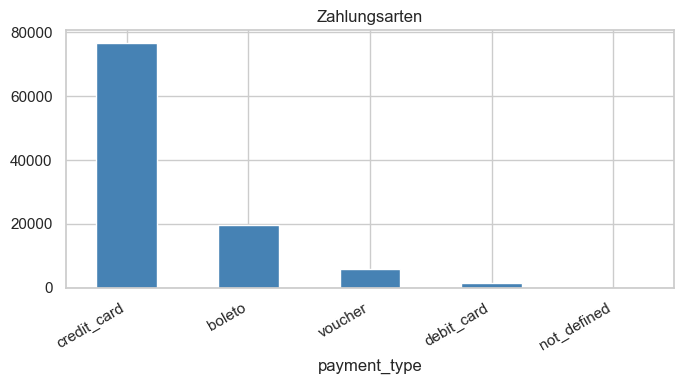

In [12]:
print(payments['payment_type'].value_counts())
print(f"\nØ Raten (installments): {payments['payment_installments'].mean():.1f}")

# Zahlungsarten
payments['payment_type'].value_counts().plot(kind='bar', color='steelblue', figsize=(7,4))
plt.title('Zahlungsarten')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## 4. olist_order_reviews_dataset  
Kundenbewertungen (1–5 Sterne) + Kommentare. Nicht jede Bestellung hat eine Bewertung.

Relevant für: BQ-04 (Kundenzufriedenheit)

In [13]:
reviews = pd.read_csv(RAW / 'olist_order_reviews_dataset.csv', parse_dates=[
    'review_creation_date', 'review_answer_timestamp'
])
profile(reviews, 'order_reviews')


===== order_reviews =====
Shape:      99,224 Zeilen × 7 Spalten
Duplikate:  0

                                  dtype  nulls  null_%
review_id                           str      0    0.00
order_id                            str      0    0.00
review_score                      int64      0    0.00
review_comment_title                str  87656   88.34
review_comment_message              str  58247   58.70
review_creation_date     datetime64[us]      0    0.00
review_answer_timestamp  datetime64[us]      0    0.00

--- Stichprobe (3 Zeilen) ---


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
90252,406e32984dd5273582105460a79571af,e00ed9d20c3479f9f0e9727ca9d60946,5,NaN,NaN,2017-12-22,2017-12-22 21:10:19
24436,3bca8d9922bed47eb96f23d121945290,3b5351f5f99b46339212291661a9d226,5,NaN,Cumpriu o acordado!,2018-04-10,2018-04-13 01:57:05
11313,65895b807ac5dfe062c82400b3f210b8,f395e98fb5c1c6ce1306e80de2fe125b,4,NaN,NaN,2017-04-20,2017-04-21 11:31:32


Ø Bewertungsscore:  4.09
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


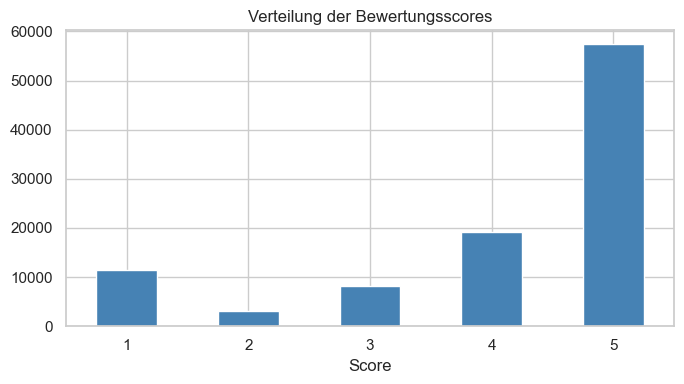

In [14]:
print(f"Ø Bewertungsscore:  {reviews['review_score'].mean():.2f}")
print(reviews['review_score'].value_counts().sort_index())

reviews['review_score'].value_counts().sort_index().plot(
    kind='bar', color='steelblue', figsize=(7,4)
)
plt.title('Verteilung der Bewertungsscores')
plt.xlabel('Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
## 5. olist_customers_dataset  
Kundenstammdaten inkl. Stadt und Bundesstaat.

Relevant für: BQ-02 (Regionale Performance)

In [15]:
customers = pd.read_csv(RAW / 'olist_customers_dataset.csv')
profile(customers, 'customers')


===== customers =====
Shape:      99,441 Zeilen × 5 Spalten
Duplikate:  0

                          dtype  nulls  null_%
customer_id                 str      0     0.0
customer_unique_id          str      0     0.0
customer_zip_code_prefix  int64      0     0.0
customer_city               str      0     0.0
customer_state              str      0     0.0

--- Stichprobe (3 Zeilen) ---


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
52263,c7432c6d237ffd6aa36a007b4237ec38,9a897ea48bf988012c00b802f1104a92,2971,sao paulo,SP
46645,7f399d641e2e2064470145178c9e8778,90436a67885a57f147fb79e6d0e4bc1c,38610,unai,MG
37546,ba5642b730704dc0f74b7cf715b41ed5,4d8056f71519ae1069e6747c63c676f7,88820,icara,SC


In [16]:
print(f"Unique Kunden:       {customers['customer_unique_id'].nunique():,}")
print(f"Unique customer_id:  {customers['customer_id'].nunique():,}")
print(f"  → Differenz zeigt Wiederkäufer (customer_id != customer_unique_id)")

print('\nTop 10 Bundesstaaten:')
print(customers['customer_state'].value_counts().head(10))

Unique Kunden:       96,096
Unique customer_id:  99,441
  → Differenz zeigt Wiederkäufer (customer_id != customer_unique_id)

Top 10 Bundesstaaten:
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64


---
## 6. olist_sellers_dataset  
Verkäuferstammdaten inkl. Bundesstaat.

Relevant für: BQ-02 (Seller-Regionen)

In [17]:
sellers = pd.read_csv(RAW / 'olist_sellers_dataset.csv')
profile(sellers, 'sellers')
print('\nTop 10 Seller-Bundesstaaten:')
print(sellers['seller_state'].value_counts().head(10))


===== sellers =====
Shape:      3,095 Zeilen × 4 Spalten
Duplikate:  0

                        dtype  nulls  null_%
seller_id                 str      0     0.0
seller_zip_code_prefix  int64      0     0.0
seller_city               str      0     0.0
seller_state              str      0     0.0

--- Stichprobe (3 Zeilen) ---


,seller_id,seller_zip_code_prefix,seller_city,seller_state
1947,1f7fd2a6fcd5a6fa5d8a4dabc72aaae0,95800,venancio aires,RS
1309,6e1862e15f33d9994bc25922a85e1efc,13505,rio claro,SP
1606,e628d4a53c109f09ca88098338b3a3f5,30170,belo horizonte,MG



Top 10 Seller-Bundesstaaten:
seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
Name: count, dtype: int64


---
## 7. olist_products_dataset  
Produktkatalog mit Kategorie, Abmessungen, Gewicht.

Relevant für: BQ-01 (Kategorie-Umsatz)

In [18]:
products = pd.read_csv(RAW / 'olist_products_dataset.csv')
profile(products, 'products')


===== products =====
Shape:      32,951 Zeilen × 9 Spalten
Duplikate:  0

                              dtype  nulls  null_%
product_id                      str      0    0.00
product_category_name           str    610    1.85
product_name_lenght         float64    610    1.85
product_description_lenght  float64    610    1.85
product_photos_qty          float64    610    1.85
product_weight_g            float64      2    0.01
product_length_cm           float64      2    0.01
product_height_cm           float64      2    0.01
product_width_cm            float64      2    0.01

--- Stichprobe (3 Zeilen) ---


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
24880,f819f0c84a64f02d3a5606ca95edd272,relogios_presentes,59.0,452.0,1.0,710.0,19.0,13.0,14.0
6366,b9de40e43fccb6ba53b7eadbd5c49077,utilidades_domesticas,41.0,1188.0,3.0,700.0,70.0,10.0,15.0
4989,26afe4ed5890d941fcba14205863eec7,moveis_decoracao,47.0,1092.0,1.0,3850.0,30.0,30.0,30.0


In [19]:
print(f"Unique Kategorien: {products['product_category_name'].nunique()}")
print(f"Fehlende Kategorien: {products['product_category_name'].isnull().sum()}")
print('\nTop 15 Kategorien (Anzahl Produkte):')
print(products['product_category_name'].value_counts().head(15))

Unique Kategorien: 73
Fehlende Kategorien: 610

Top 15 Kategorien (Anzahl Produkte):
product_category_name
cama_mesa_banho                3029
esporte_lazer                  2867
moveis_decoracao               2657
beleza_saude                   2444
utilidades_domesticas          2335
automotivo                     1900
informatica_acessorios         1639
brinquedos                     1411
relogios_presentes             1329
telefonia                      1134
bebes                           919
perfumaria                      868
papelaria                       849
fashion_bolsas_e_acessorios     849
cool_stuff                      789
Name: count, dtype: int64


---
## 8. product_category_name_translation  
Übersetzung portugiesisch → englisch für Kategorienamen.

In [20]:
translation = pd.read_csv(RAW / 'product_category_name_translation.csv')
profile(translation, 'category_translation')

# Gibt es Kategorien in products, die keine Übersetzung haben?
cats_in_products = set(products['product_category_name'].dropna())
cats_translated  = set(translation['product_category_name'])
missing_translation = cats_in_products - cats_translated
print(f"\nKategorien ohne Übersetzung ({len(missing_translation)}): {missing_translation}")


===== category_translation =====
Shape:      71 Zeilen × 2 Spalten
Duplikate:  0

                              dtype  nulls  null_%
product_category_name           str      0     0.0
product_category_name_english   str      0     0.0

--- Stichprobe (3 Zeilen) ---


,product_category_name,product_category_name_english
22,cool_stuff,cool_stuff
0,beleza_saude,health_beauty
49,construcao_ferramentas_seguranca,construction_tools_safety



Kategorien ohne Übersetzung (2): {'portateis_cozinha_e_preparadores_de_alimentos', 'pc_gamer'}


---
## 9. olist_geolocation_dataset  
PLZ → Lat/Lon-Mapping. Sehr groß (1M+ Zeilen), viele Duplikate — wird aggregiert verwendet.

In [21]:
geo = pd.read_csv(RAW / 'olist_geolocation_dataset.csv')
profile(geo, 'geolocation')

print(f"Unique PLZs: {geo['geolocation_zip_code_prefix'].nunique():,}")
print(f"→ Mehrfacheinträge pro PLZ sind normal (mehrere Koordinaten-Messpunkte)")


===== geolocation =====
Shape:      1,000,163 Zeilen × 5 Spalten
Duplikate:  261,831

                               dtype  nulls  null_%
geolocation_zip_code_prefix    int64      0     0.0
geolocation_lat              float64      0     0.0
geolocation_lng              float64      0     0.0
geolocation_city                 str      0     0.0
geolocation_state                str      0     0.0

--- Stichprobe (3 Zeilen) ---


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
162456,6412,-23.497836,-46.882982,barueri,SP
65543,3707,-23.507041,-46.543324,sao paulo,SP
129566,5406,-23.555752,-46.674463,são paulo,SP


Unique PLZs: 19,015
→ Mehrfacheinträge pro PLZ sind normal (mehrere Koordinaten-Messpunkte)


---
## 10. Beziehungen prüfen — Referenzielle Integrität

**Warum wichtig?** Fehlende Joins würden in der Pipeline zu stille Datenverlust führen —  
z.B. Bestellungen ohne Produkt-Info würden aus dem Umsatz-KPI rausfallen.

In [ ]:
def check_fk(left_df, left_col, right_df, right_col, label: str) -> None:
    """Prüft ob alle Werte in left_col auch in right_col vorkommen."""
    orphans = ~left_df[left_col].isin(right_df[right_col])
    n = orphans.sum()
    pct = orphans.mean() * 100
    status = '✓' if n == 0 else '⚠'
    print(f"{status}  {label}: {n:,} Waisen ({pct:.2f}%)")

print('=== Referenzielle Integrität ===\n')
check_fk(items,    'order_id',    orders,    'order_id',    'items       → orders')
check_fk(payments, 'order_id',    orders,    'order_id',    'payments    → orders')
check_fk(reviews,  'order_id',    orders,    'order_id',    'reviews     → orders')
check_fk(orders,   'customer_id', customers, 'customer_id', 'orders      → customers')
check_fk(items,    'product_id',  products,  'product_id',  'items       → products')
check_fk(items,    'seller_id',   sellers,   'seller_id',   'items       → sellers')

=== Referenzielle Integrität ===

✓  items       → orders: 0 Waisen (0.00%)
✓  payments    → orders: 0 Waisen (0.00%)
✓  reviews     → orders: 0 Waisen (0.00%)
✓  orders      → customers: 0 Waisen (0.00%)
✓  items       → products: 0 Waisen (0.00%)
✓  items       → sellers: 0 Waisen (0.00%)


---
## 11. Missing Values Visualisierung (gesamt)

Missingno zeigt auf einen Blick welche Spalten lückenhaft sind — wichtig für Null-Handling in Glue/dbt.


--- orders ---


C:\Users\User\AppData\Local\Temp\ipykernel_21372\49152415.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


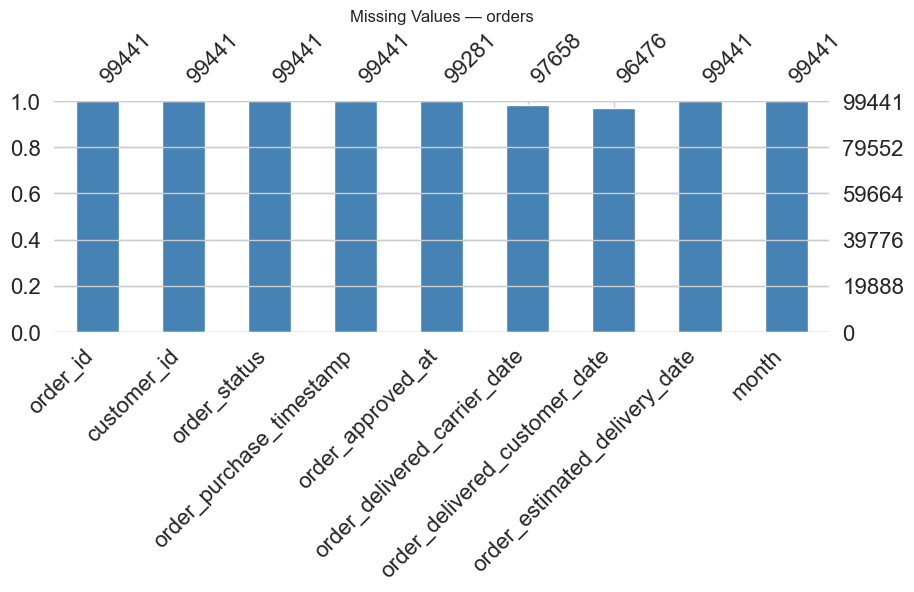


--- reviews ---


C:\Users\User\AppData\Local\Temp\ipykernel_21372\49152415.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


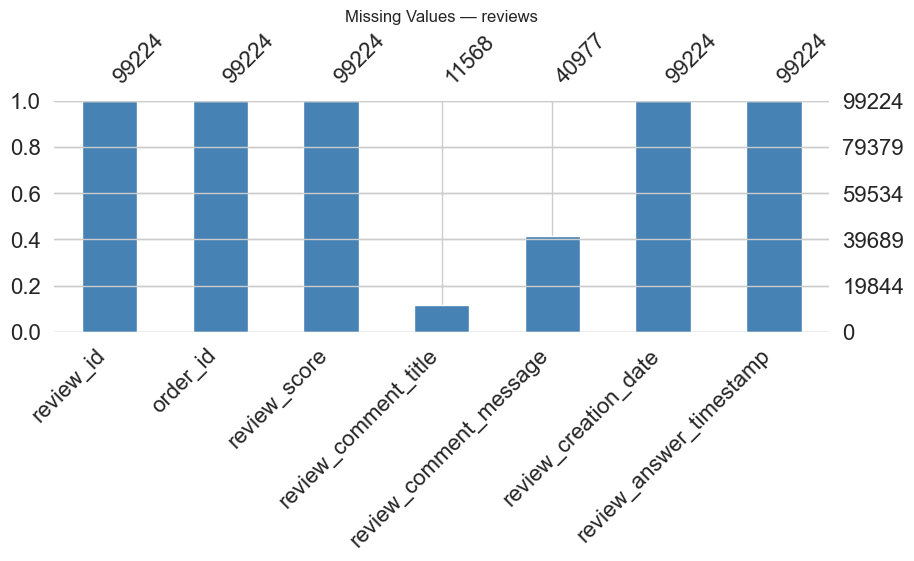


--- products ---


C:\Users\User\AppData\Local\Temp\ipykernel_21372\49152415.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


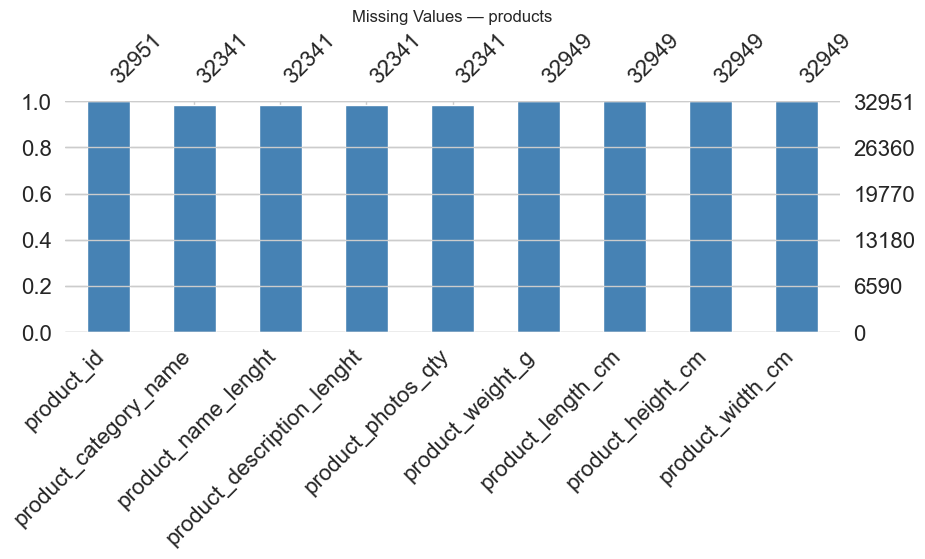

In [23]:
for df, name in [
    (orders,   'orders'),
    (items,    'order_items'),
    (payments, 'payments'),
    (reviews,  'reviews'),
    (products, 'products'),
]:
    if df.isnull().any().any():
        print(f'\n--- {name} ---')
        msno.bar(df, figsize=(10, 3), color='steelblue')
        plt.title(f'Missing Values — {name}')
        plt.tight_layout()
        plt.show()

---
## 12. EDA-Befunde & Pipeline-Implikationen

### Datenqualität

| # | Tabelle | Spalte | Befund | Maßnahme |
|---|---------|--------|--------|-----------|
| 1 | olist_orders | `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date` | Nulls vorhanden, geringer Anteil | Lassen — logisch bedingt durch Bestellstatus. In dbt bei Lieferdauer auf `IS NOT NULL` filtern |
| 2 | olist_order_reviews | `review_comment_message`, `review_comment_title` | Sehr hoher Null-Anteil | Lassen — Freitext optional. Für BQ-04 nur `review_score` relevant, vollständig vorhanden |
| 3 | olist_products | `product_category_name` | 1.85% Nulls | Fallback `'unknown'` in AWS Glue (`fillna('unknown')`). Nicht droppen — Zeilen enthalten echten Umsatz |

### Referenzielle Integrität

| Beziehung | Ergebnis |
|-----------|----------|
| order_items → orders | ✓ Keine Waisen |
| payments → orders | ✓ Keine Waisen |
| reviews → orders | ✓ Keine Waisen |
| orders → customers | ✓ Keine Waisen |
| items → products | ✓ Keine Waisen |
| items → sellers | ✓ Keine Waisen |

→ Alle JOINs verlustfrei. Kein Sonderhandling nötig.

### Sonstiges

| # | Befund | Relevanz |
|---|--------|----------|
| 1 | IDs (`order_id`, `customer_id` etc.) sind UUIDs als String | Korrekt — in Redshift als `VARCHAR` speichern |
| 2 | Geolocation: 1M+ Zeilen, Mehrfacheinträge pro PLZ | In Glue auf Median-Koordinate pro PLZ aggregieren |
| 3 | `customer_unique_id` ≠ `customer_id` | `customer_unique_id` für Wiederkäufer-Analyse, `customer_id` nur als JOIN-Key zu orders |
| 4 | Kategorie-Übersetzung PT→EN vorhanden | In dbt `dim_products` per JOIN ergänzen, COALESCE auf PT-Namen als Fallback |
| 5 | Keine referenziellen Integritätsprobleme | Überdurchschnittlich sauberer Datensatz |

### Offene Entscheidungen für dbt-Modellierung
- Geolocation: Median-Koordinate pro PLZ als Aggregationsstrategie
- `product_category_name`: Fallback `'unknown'` bereits entschieden
- Kategorie-Übersetzung: JOIN in `dim_products` mit COALESCE-Fallback
